In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




,ID,herd,HYS,parity,ACC,lact_week,avgCH4,speaks,npeaks,avgCO2,ratio,CH4gr,MeI,peID
,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,98905,1,69,3,88,13,NA,NA,NA,6172.62,NA,NA,NA,98905
2,98905,1,71,3,102,53,365.00,1957.99,1.96,7370.22,0.03,NA,NA,98905
3,98905,1,69,3,88,8,NA,NA,NA,7053.29,NA,NA,NA,98905
4,98905,1,71,3,102,52,601.92,2360.75,1.96,7876.21,0.06,NA,NA,98905
5,98905,1,69,3,88,12,NA,NA,NA,6581.15,NA,NA,NA,98905
6,98905,1,69,3,88,9,NA,NA,NA,6739.47,NA,NA,NA,98905


[1] 13366    14

       ID              herd            HYS            parity     
 Min.   : 27160   Min.   :1.000   Min.   : 3.00   Min.   :1.000  
 1st Qu.: 89963   1st Qu.:1.000   1st Qu.:11.00   1st Qu.:1.000  
 Median :112116   Median :2.000   Median :35.00   Median :2.000  
 Mean   : 91136   Mean   :2.207   Mean   :38.74   Mean   :1.947  
 3rd Qu.:112594   3rd Qu.:2.000   3rd Qu.:71.00   3rd Qu.:3.000  
 Max.   :140563   Max.   :5.000   Max.   :82.00   Max.   :3.000  
                                                                 
      ACC           lact_week         avgCH4            speaks       
 Min.   : 17.00   Min.   : 0.00   Min.   :   1.34   Min.   :   0.27  
 1st Qu.: 24.00   1st Qu.:12.00   1st Qu.: 403.72   1st Qu.: 573.97  
 Median : 36.00   Median :20.50   Median : 574.35   Median : 690.91  
 Mean   : 42.47   Mean   :21.88   Mean   : 535.19   Mean   : 819.44  
 3rd Qu.: 52.00   3rd Qu.:31.00   3rd Qu.: 686.87   3rd Qu.: 859.65  
 Max.   :120.00   Max.   :59.00   Max.   :1079.84   

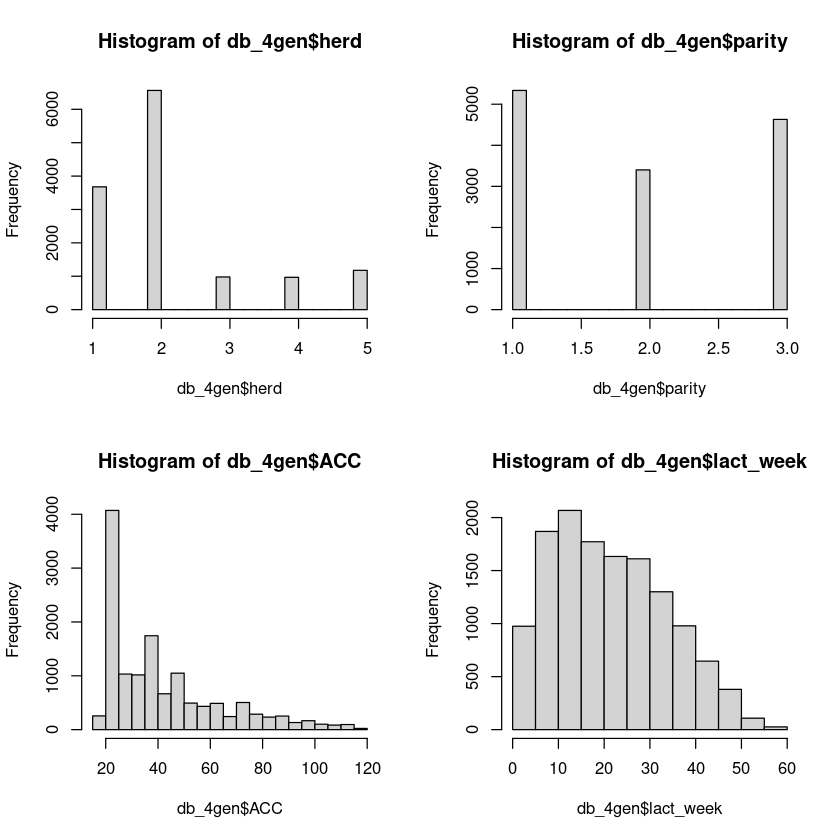

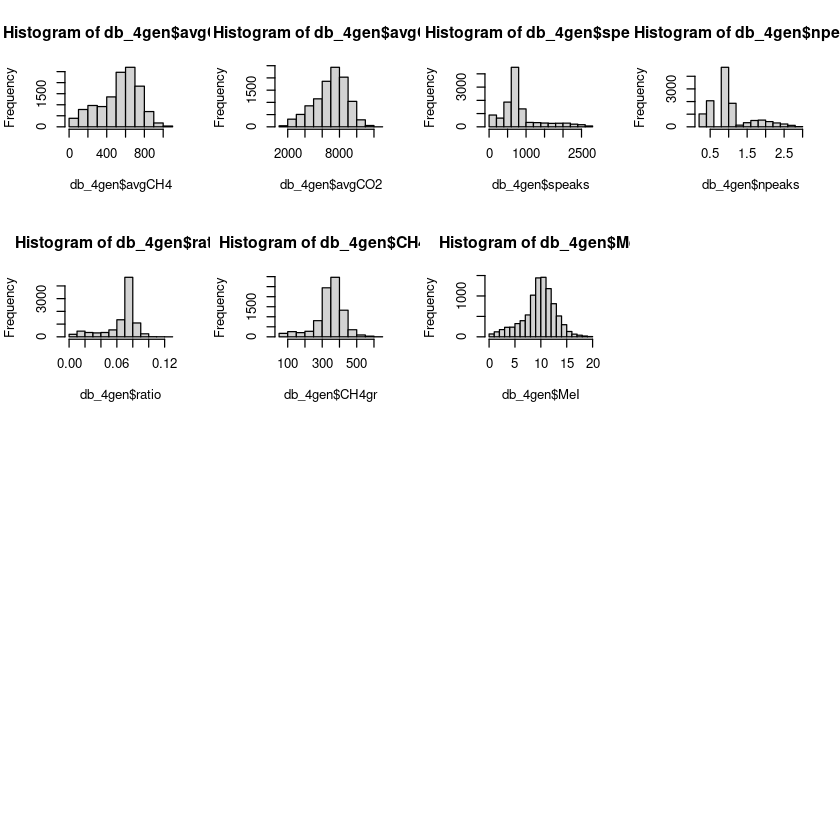

In [2]:
db_4gen <- read.table("dat.dat", sep = ",", stringsAsFactors = F, header = F)  
colnames(db_4gen) = c("ID", "herd", "HYS", "parity", "ACC", "lact_week", "avgCH4", "speaks", "npeaks", "avgCO2", "ratio", "CH4gr", "MeI", "peID")
head(db_4gen)
dim(db_4gen)
summary(db_4gen)

par(mfrow = c(2, 2))
hist(db_4gen$herd)
hist(db_4gen$parity)
hist(db_4gen$ACC)
hist(db_4gen$lact_week)

par(mfrow = c(4, 4))
hist(db_4gen$avgCH4)
hist(db_4gen$avgCO2)
hist(db_4gen$speaks)
hist(db_4gen$npeaks)
hist(db_4gen$ratio)
hist(db_4gen$CH4gr)
hist(db_4gen$MeI)

,ID,herd,HYS,parity,ACC,lact_week,avgCH4,speaks,npeaks,avgCO2,ratio,CH4gr,MeI,peID
,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,98905,1,69,3,88,13,NA,NA,NA,6172.62,NA,NA,NA,98905
2,98905,1,69,3,88,8,NA,NA,NA,7053.29,NA,NA,NA,98905
3,98905,1,69,3,88,12,NA,NA,NA,6581.15,NA,NA,NA,98905
4,98905,1,69,3,88,9,NA,NA,NA,6739.47,NA,NA,NA,98905
5,98905,1,69,3,88,11,NA,NA,NA,7003.37,NA,NA,NA,98905
6,98905,1,69,3,88,14,NA,NA,NA,6590.55,NA,NA,NA,98905


[1] 12206    14

       ID              herd            HYS           parity     
 Min.   : 27160   Min.   :1.000   Min.   : 3.0   Min.   :1.000  
 1st Qu.: 89963   1st Qu.:1.000   1st Qu.:11.0   1st Qu.:1.000  
 Median :108783   Median :2.000   Median :35.0   Median :2.000  
 Mean   : 91125   Mean   :2.192   Mean   :39.5   Mean   :1.958  
 3rd Qu.:112584   3rd Qu.:2.000   3rd Qu.:72.0   3rd Qu.:3.000  
 Max.   :140561   Max.   :5.000   Max.   :82.0   Max.   :3.000  
                                                                
      ACC           lact_week         avgCH4            speaks       
 Min.   : 17.00   Min.   : 0.00   Min.   :   1.34   Min.   :   0.27  
 1st Qu.: 24.00   1st Qu.:11.00   1st Qu.: 398.58   1st Qu.: 576.75  
 Median : 36.00   Median :19.00   Median : 575.54   Median : 697.90  
 Mean   : 42.81   Mean   :19.62   Mean   : 535.50   Mean   : 831.95  
 3rd Qu.: 53.00   3rd Qu.:28.00   3rd Qu.: 689.99   3rd Qu.: 876.61  
 Max.   :120.00   Max.   :40.00   Max.   :1079.84   Max.   :

'data.frame':	12206 obs. of  14 variables:
 $ ID       : int  98905 98905 98905 98905 98905 98905 98905 76041 76041 76041 ...
 $ herd     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ HYS      : int  69 69 69 69 69 69 69 69 69 68 ...
 $ parity   : int  3 3 3 3 3 3 3 3 3 3 ...
 $ ACC      : int  88 88 88 88 88 88 88 66 66 55 ...
 $ lact_week: int  13 8 12 9 11 14 10 18 3 4 ...
 $ avgCH4   : num  NA NA NA NA NA NA NA NA NA NA ...
 $ speaks   : num  NA NA NA NA NA NA NA NA NA NA ...
 $ npeaks   : num  NA NA NA NA NA NA NA NA NA NA ...
 $ avgCO2   : num  6173 7053 6581 6739 7003 ...
 $ ratio    : num  NA NA NA NA NA NA NA NA NA NA ...
 $ CH4gr    : num  NA NA NA NA NA NA NA NA NA NA ...
 $ MeI      : num  NA NA NA NA NA NA NA NA NA NA ...
 $ peID     : int  98905 98905 98905 98905 98905 98905 98905 76041 76041 76041 ...
'data.frame':	12206 obs. of  14 variables:
 $ ID       : int  98905 98905 98905 98905 98905 98905 98905 76041 76041 76041 ...
 $ herd     : int  1 1 1 1 1 1 1 1 1 1 ...
 $ HYS      : i

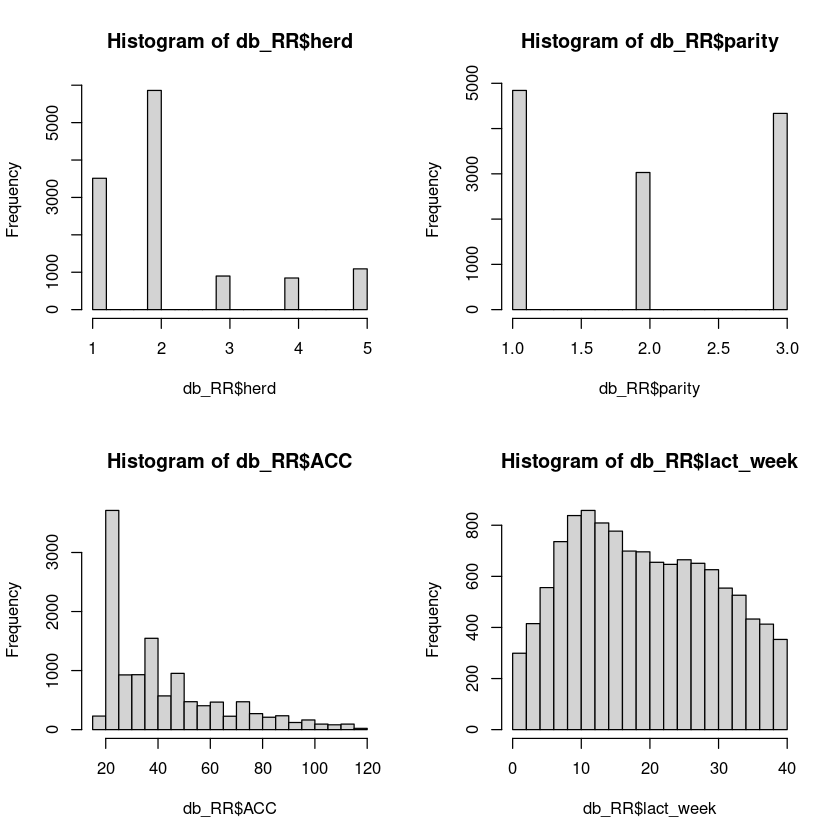

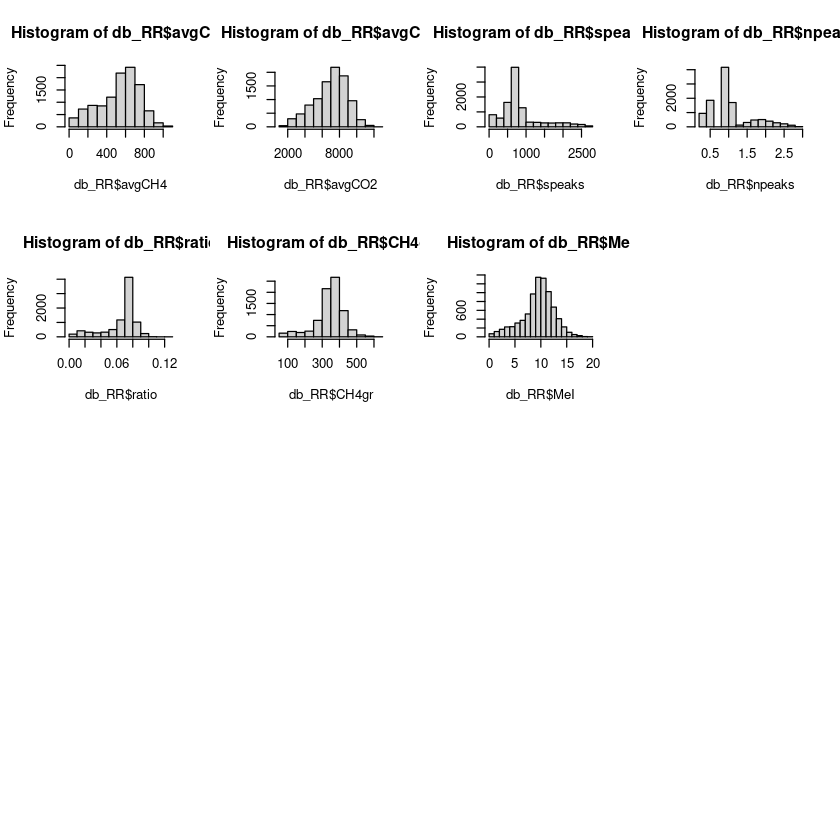

In [3]:
db_RR <- read.table("datRR.dat", sep = ",", stringsAsFactors = F, header = F)  
colnames(db_RR) = c("ID", "herd", "HYS", "parity", "ACC", "lact_week", "avgCH4", "speaks", "npeaks", "avgCO2", "ratio", "CH4gr", "MeI", "peID")
head(db_RR)
dim(db_RR)
summary(db_RR)
str(db_RR)

par(mfrow = c(2, 2))
hist(db_RR$herd)
hist(db_RR$parity)
hist(db_RR$ACC)
hist(db_RR$lact_week)

par(mfrow = c(4, 4))
hist(db_RR$avgCH4)
hist(db_RR$avgCO2)
hist(db_RR$speaks)
hist(db_RR$npeaks)
hist(db_RR$ratio)
hist(db_RR$CH4gr)
hist(db_RR$MeI)

str(db_RR)

In [4]:
cor(db_4gen$avgCH4, db_4gen$avgCO2, use="complete.obs")
cor(db_4gen$avgCH4, db_4gen$ratio, use="complete.obs")
cor(db_4gen$avgCH4, db_4gen$npeaks, use="complete.obs")
cor(db_4gen$avgCH4, db_4gen$speaks, use="complete.obs")
cor(db_4gen$avgCH4, db_4gen$CH4gr, use="complete.obs")
cor(db_4gen$avgCH4, db_4gen$MeI, use="complete.obs")

[1] 0.8626985

[1] 0.6555609

[1] 0.1332967

[1] 0.2785185

[1] 0.4989901

[1] 0.6048418

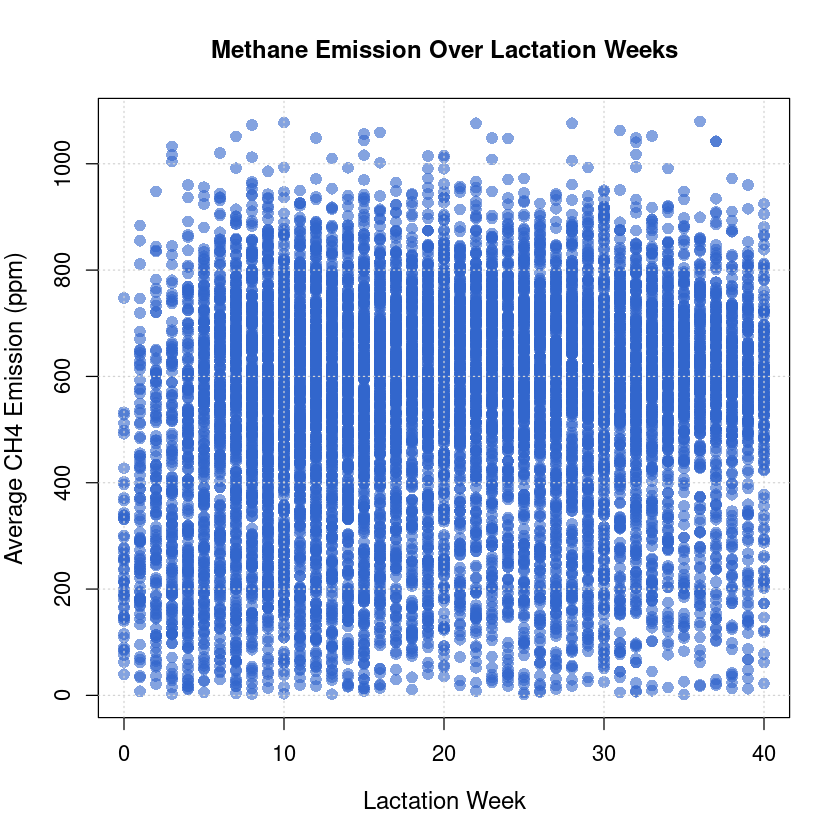

In [5]:

plot(db_RR$lact_week, db_RR$avgCH4, 
     pch = 16, col = rgb(0.2, 0.4, 0.8, 0.6), 
     main = "Methane Emission Over Lactation Weeks", 
     xlab = "Lactation Week", 
     ylab = "Average CH4 Emission (ppm)", 
     cex = 1.3, cex.lab = 1.2, cex.axis = 1.1)
grid()


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


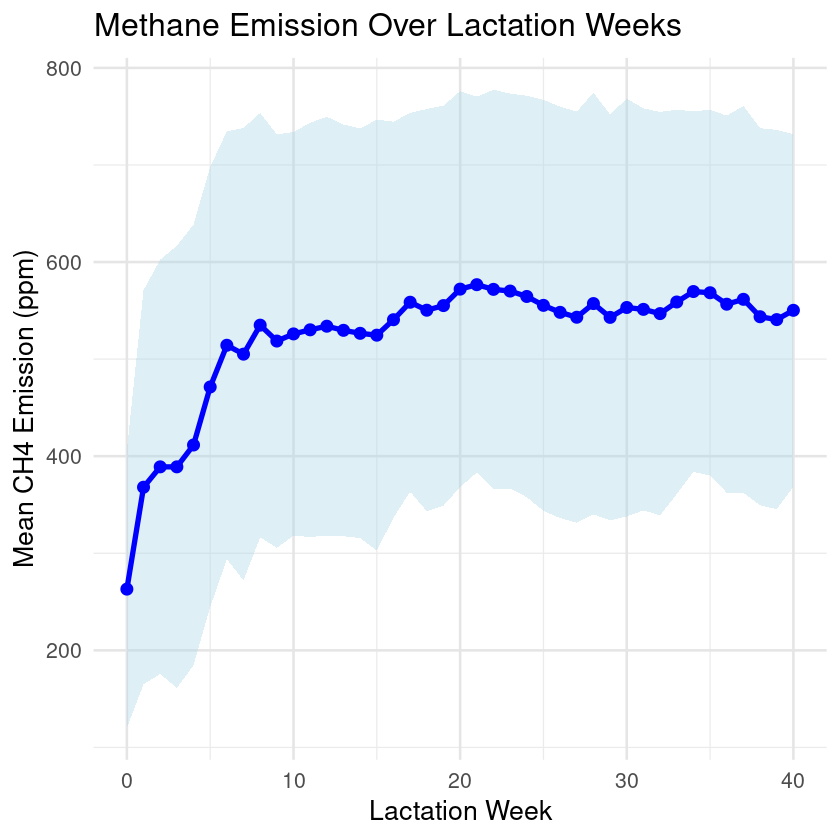

In [6]:
library(ggplot2)
library(dplyr)

# mean and SD
agg_data <- db_RR %>%
  group_by(lact_week) %>%
  summarise(mean_CH4 = mean(avgCH4, na.rm = TRUE), 
            sd_CH4 = sd(avgCH4, na.rm = TRUE))

# Plot with ggplot
ggplot(agg_data, aes(x = lact_week, y = mean_CH4)) +
  # Shaded SD area
  geom_ribbon(aes(ymin = mean_CH4 - sd_CH4, ymax = mean_CH4 + sd_CH4), 
              fill = "lightblue", alpha = 0.4) +
  # Mean line
  geom_line(color = "blue", size = 1.5) +
  # Mean points
  geom_point(color = "blue", size = 3) +
  # Custom styling
  theme_minimal(base_size = 16) +
  labs(title = "Methane Emission Over Lactation Weeks",
       x = "Lactation Week",
       y = "Mean CH4 Emission (ppm)") +
  theme(panel.grid.major = element_line(color = "gray90"))


`geom_smooth()` using formula = 'y ~ x'


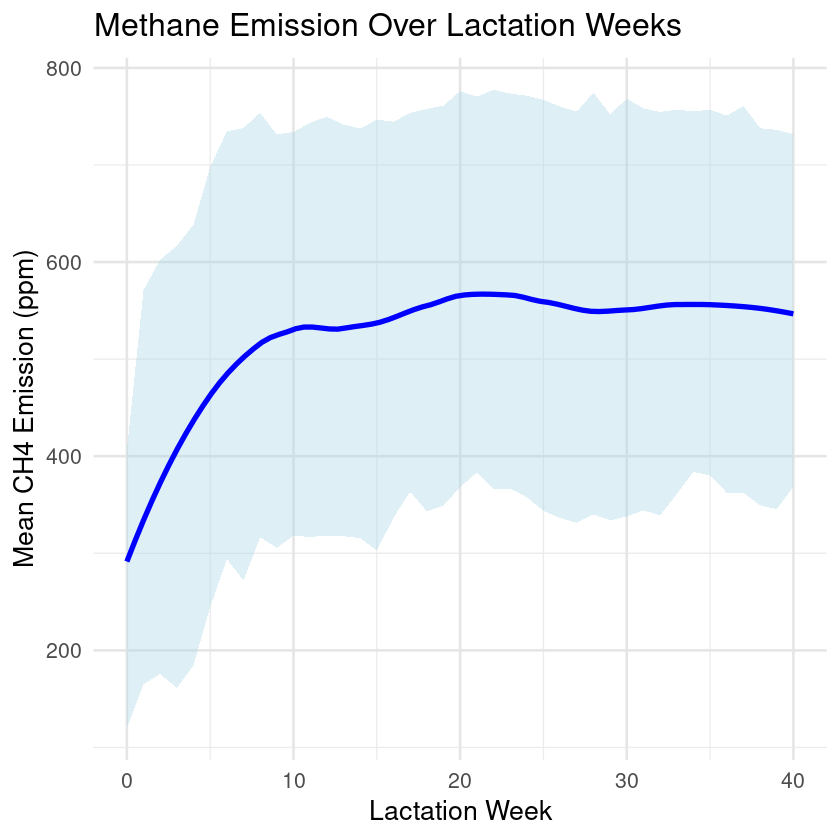

In [7]:

# Plot with ggplot & smooth
ggplot(agg_data, aes(x = lact_week, y = mean_CH4)) +
  # Shaded SD area
  geom_ribbon(aes(ymin = mean_CH4 - sd_CH4, ymax = mean_CH4 + sd_CH4), 
              fill = "lightblue", alpha = 0.4) +
  # Smooth mean line
  geom_smooth(color = "blue", fill = "blue", method = "loess", 
              se = FALSE, size = 1.5, span = 0.5) + 
  # Custom styling
  theme_minimal(base_size = 16) +
  labs(title = "Methane Emission Over Lactation Weeks",
       x = "Lactation Week",
       y = "Mean CH4 Emission (ppm)") +
  theme(panel.grid.major = element_line(color = "gray90"))

